In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import config
import numpy as np

In [3]:
df_train = pd.read_csv(config.path.train)
df_test = pd.read_csv(config.path.test)
display(df_train.shape)
display(df_train.duplicated().sum())
display(df_train.head(2))
display(df_test.shape)
display(df_test.duplicated().sum())
display(df_test.head(2))

(891, 12)

np.int64(0)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


(418, 11)

np.int64(0)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [3]:
df_train.info()
display(df_train.select_dtypes(include=['float64']).columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


['Age', 'Fare']

In [4]:
null_values = df_train.isna().sum().loc[lambda x: x > 0]
display(pd.DataFrame({
    'null_values': null_values.values,
    'dtype': df_train[null_values.index].dtypes,
    'unique_values': df_train[null_values.index].nunique()
}, index=null_values.index))
display(df_train[null_values.index].head(5))
# посмотреть nan распределение

,null_values,dtype,unique_values
Age,177,float64,88
Cabin,687,str,147
Embarked,2,str,3


,Age,Cabin,Embarked
0,22.0,NaN,S
1,38.0,C85,C
2,26.0,NaN,S
3,35.0,C123,S
4,35.0,NaN,S


In [5]:
null_values = df_test.isna().sum().loc[lambda x: x > 0]
display(pd.DataFrame({
    'null_values': null_values.values,
    'dtype': df_test[null_values.index].dtypes,
    'unique_values': df_test[null_values.index].nunique()
}, index=null_values.index))

,null_values,dtype,unique_values
Age,86,float64,79
Fare,1,float64,169
Cabin,327,str,76


In [8]:
num_cols = df_train.select_dtypes(include=['int', 'float']).columns.tolist()
cat_cols = df_train.select_dtypes(include=['str', 'category', 'object']).columns.tolist()
display(len(num_cols),
        len(cat_cols))
target = df_train['Survived']

7

5

count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64

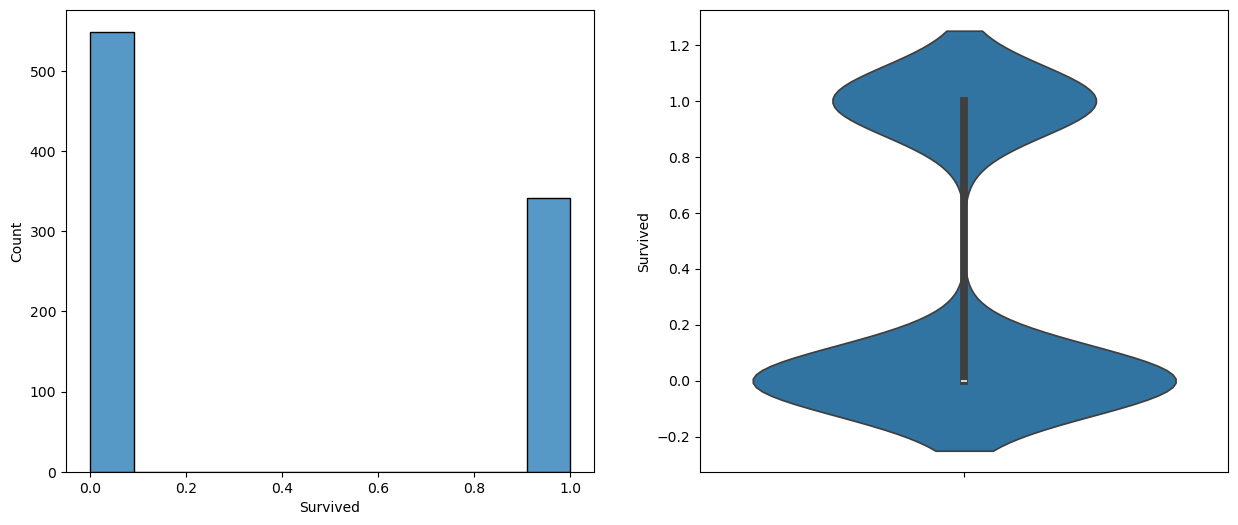

In [12]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
sns.histplot(target)
plt.subplot(1,2,2)
sns.violinplot(target)
display(target.describe())
plt.show()

In [17]:
display(df_train[num_cols].corr())
corr = df_train.drop(columns=['PassengerId']).corr(numeric_only=True)['Survived'].sort_values(ascending=False).head(11)
# # много корр фичей стоит подумать над основными и наиболее важными в контексте price на дом

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


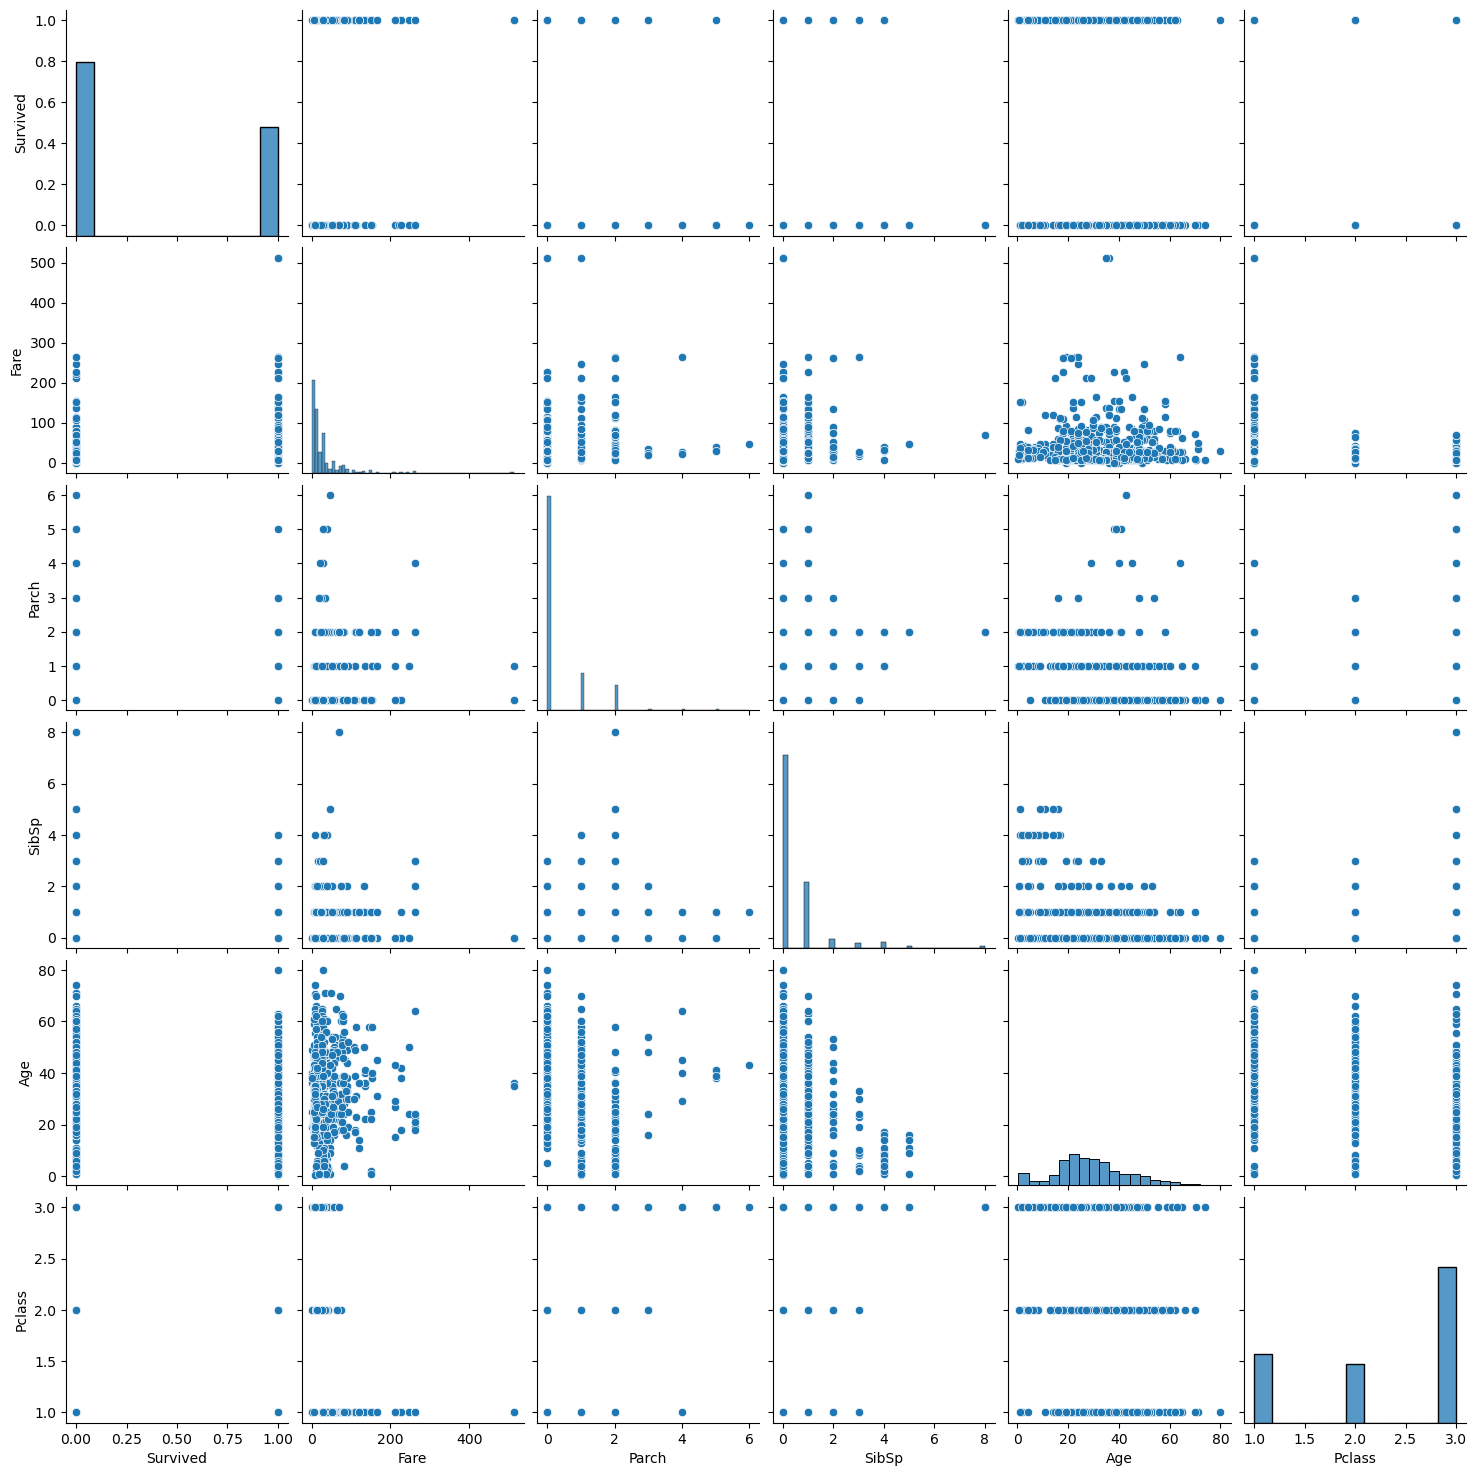

In [18]:
sns.pairplot(data = df_train[corr.index])
plt.show()

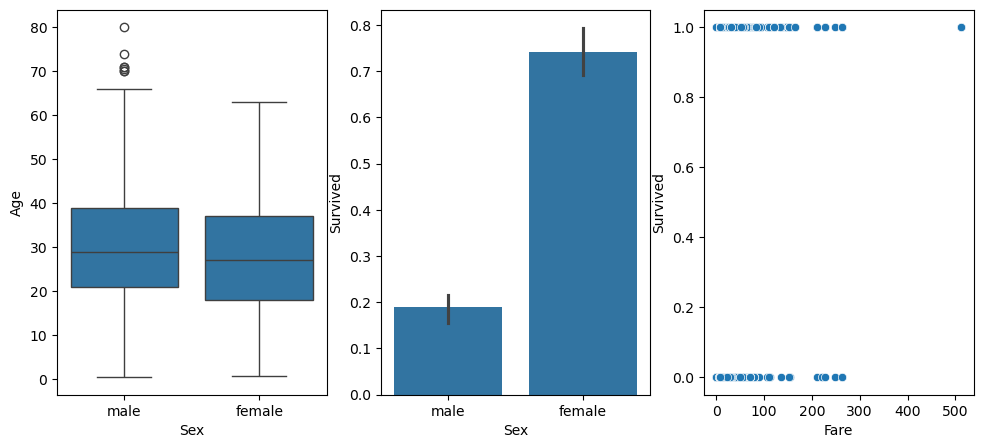

In [55]:
plt.figure(figsize=(16,5))
plt.subplot(1,4,1)
sns.boxplot(data=df_train,
            x='Sex',
            y='Age'
        )
plt.subplot(1,4,2)
sns.barplot(data=df_train,
            x='Sex',
            y=target
        )
plt.subplot(1,4,3)
sns.scatterplot(data=df_train,
                x='Fare',
                y=target)
plt.show()

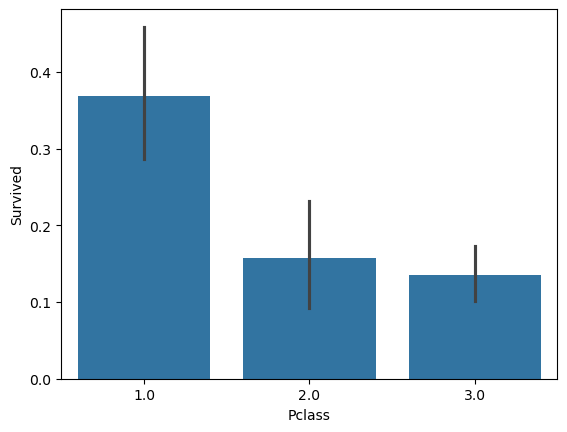

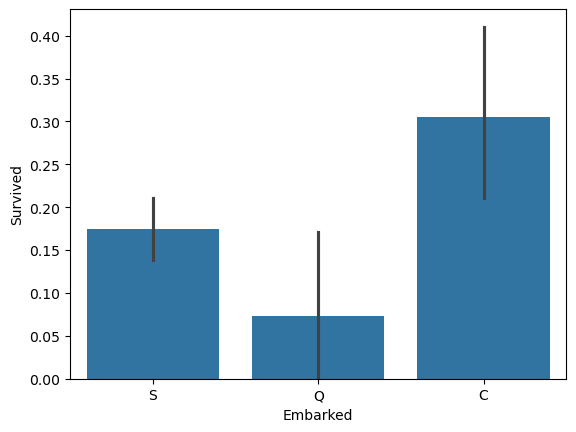

In [57]:
sns.barplot(df_train[df_train['Sex'] == 'male'],
                x='Pclass',
                y=target)
plt.show()
sns.barplot(df_train[df_train['Sex'] == 'male'],
                x='Embarked',
                y=target)
plt.show()

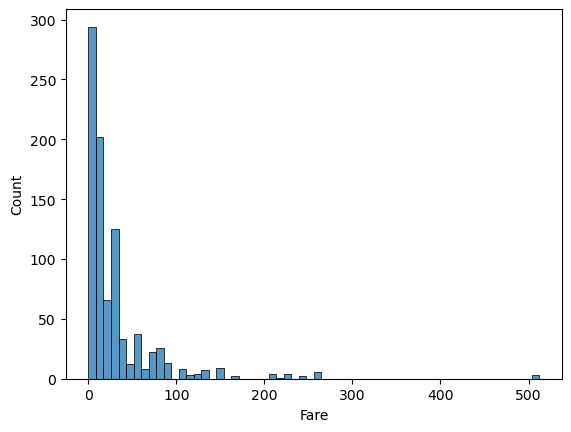

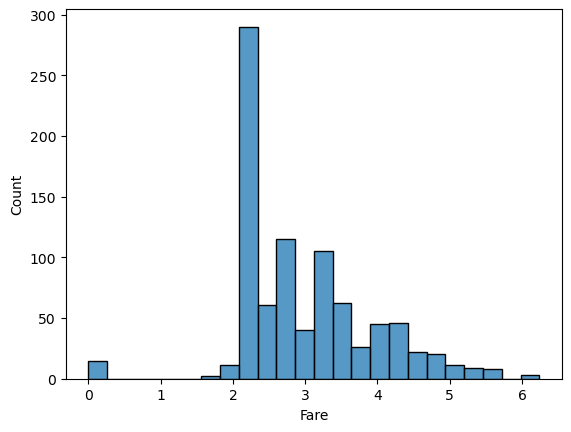

In [21]:
sns.histplot(data=df_train,
             x='Fare')
plt.show()
sns.histplot(np.log1p(df_train['Fare']))
plt.show()